In [3]:
from analyzer import * 
sns.set_style('whitegrid') 

/home/work/.anaconda/envs/privacyovod_new_copy/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'sns' is not defined

# MMStar 

In [ ]:
mm = MMStarResults()
# answers_pivot = mm.combine_mh(model_acc=mm.model_mc) 
md = mm.model_mc 
md=md[md['condition'] == 'inst blind']
vlms=md[md['model_type'] != 'llm'].model.unique() 
llms=md[md['model_type'] == 'llm'].model.unique() 
all_humans = mm.human.participant_id.unique()   
md.finetuned.unique()  

In [353]:
hm_acc = mm.human.groupby([ 'category', 'l2_category', 'question_id'])['correct'].mean().reset_index()
alignment_results = []
n_boot = 1000

for vlm in md.model.unique() : 

    hm = pd.merge(hm_acc, md[md['model'] == vlm], 
                    on=['category', 'l2_category', 'question_id'], 
                    how='inner',
                    suffixes=("_human", '_model'))  

    for ft in hm.finetuned.unique(): 
        theta_hat = pairwise_metric(hm[hm['finetuned']==ft]['correct_model'].values, 
                                    hm[hm['finetuned']==ft]['correct_human'].values )  
        
        if n_boot: 
            boot =  bootstrap_spearman(hm[hm['finetuned']==ft]['correct_model'].values, hm[hm['finetuned']==ft]['correct_human'].values, n_boot, 42) 
            ci = np.percentile(boot, [2.5, 97.5]) # 95% percentile CI

        alignment_results.append({
            'model': vlm, 
            'theta_hat': theta_hat, 
            "ci": ci,
            "finetuned": ft, 
            # 'data': hm 
        }) 

In [791]:
df = pd.DataFrame(alignment_results) 
### Filter invalid model 
df = df[df['model'] != 'Qwen3 Base (8B)' ]
# df = df[df['finetuned'] == 'Pretrained']
df['dataset'] = "MMStar"

ci_lows = np.array([c[0] for c in df.ci.values]) # np.array([alignment_results[m]["ci"][0] for m in models])
ci_highs = np.array([c[1] for c in df.ci.values]) # np.array([alignment_results[m]["ci"][1] for m in models])

models = df.model.values # list(alignment_results.keys())
rhos = df.theta_hat.values # np.array([alignment_results[m]["theta_hat"] for m in models])

human_correct =mm.human.pivot( index=['participant_id'], columns=['question_id'], values=['correct']).to_numpy()
human_correct = (human_correct > 0).astype(int)
human_rhos = human_vs_consensus(human_correct) 
low, high = np.percentile(human_rhos, [2.5, 97.5])
mu, sd = human_rhos.mean(), human_rhos.std() 
human_correct.shape , mu, sd 

((20, 247), 0.290796260316054, 0.09906076795651508)

In [358]:
# Example: Add a new row with sample values. You can adjust the values as needed.
new_row = {
    'model': 'humans',
    'theta_hat': mu,
    'ci': [low, high],
    'finetuned': 'humans',
    'dataset': 'MMStar'
}
df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
df = df.dropna(axis=0) 
df.to_json('./correlations/mmstar.json')
df

,model,theta_hat,ci,finetuned,dataset
0,InternVL 3.5 (1B),0.127259,"[0.01807723636027576, 0.24007046518527747]",Pretrained,MMStar
1,InternVL 3.5 (2B),0.182182,"[0.06843183181116226, 0.2951462527712584]",Pretrained,MMStar
2,InternVL 3.5 (4B),0.118522,"[-0.012406274713037126, 0.23398128087226605]",Pretrained,MMStar
3,InternVL 3.5 (8B),0.230196,"[0.11117597332303726, 0.33979072431682805]",Pretrained,MMStar
4,InternVL 3.5 (8B),0.200721,"[0.07695275104800336, 0.3204019650183335]",JS VQA (GT),MMStar
5,InternVL 3.5 (8B),0.258897,"[0.14586402843301557, 0.3595749240506157]",SFT-Blind MMStar (n=15),MMStar
6,InternVL 3.5 (8B),0.272275,"[0.16303810351636416, 0.3816517808137501]",JS-Blind VQA (n=10),MMStar
7,InternVL 3.5 (8B),0.270328,"[0.16464508215591736, 0.38246825038229476]",JS-Blind VQA (n=15),MMStar
8,InternVL 3.5 (8B),0.294459,"[0.186708144900753, 0.39534954344176865]",JS-Blind MMStar (n=15),MMStar
9,InternVL 3.5 (8B),0.269664,"[0.1603890305172797, 0.38562786480254263]",SFT-Blind VQA,MMStar


In [689]:
md.finetuned.unique()

array(['Pretrained', 'JS VQA (GT)', 'SFT-Blind MMStar (n=15)',
       'JS-Blind VQA (n=10)', 'JS-Blind VQA (n=15)',
       'JS-Blind MMStar (n=15)', 'SFT-Blind VQA', 'SFT-VQA',
       'SFT-Blind MMStar'], dtype=object)

In [327]:
md.groupby(['category'])['correct'].mean()

category
coarse perception          26.238390
fine-grained perception    28.322043
instance reasoning         26.842105
logical reasoning          42.105263
science & technology       28.947368
Name: correct, dtype: float64

In [328]:
mm.human.groupby(['category'])['correct'].mean() 

category
coarse perception          28.182487
fine-grained perception    26.287129
instance reasoning         28.727273
logical reasoning          28.701595
science & technology       10.000000
Name: correct, dtype: float64

In [ ]:
df = pd.read_json('./correlations/mmstar_pretrained.json') 

In [ ]:
md[(md['finetuned'] == 'Pretrained') & (md['category'] != 'science & technology')].pivot_table(index=['model'], columns=['category'], values=['correct'], 
    margins=True,
    margins_name='Average' ).to_latex('./tables/1_mmstar_blind.tex', float_format="%.1f")     

# VQA 

In [5]:
vv = VQAResults()   
human_vqa = vv.human.drop_duplicates(subset=['question_id', 'participant_id']) 
# get_agreements(human_vqa, model_vqa, metrics="correct", n_boot=200) 
model_vqa = vv.model  # only the blind condition 
human_vqa[human_vqa['question_id'] == 524577006 ].iloc[12][['processed_ans', 'correct', 'gt_answers']]  

   Loading VQA annotations from /home/work/yuna/data/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
before 38.98698056001426
after  39.8876404494382
14 6
[]
before 55.83173855421686
after  55.98475060240963
[]
before 56.35019720754123
after  56.49173244118188


/home/work/yuna/HPA/evaluation/analysis/analyzer.py:406: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['new_question_type'] = df["question_type"].apply(map_question_type)
/home/work/yuna/HPA/evaluation/analysis/analyzer.py:406: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['new_question_type'] = df["question_type"].apply(map_question_type)


processed_ans                                 1
correct                                   100.0
gt_answers       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Name: 6424, dtype: object

In [ ]:
vm = vv.model
vm = vm[vm['finetuned'] == 'Pretrained'] 

In [864]:
vm.pivot_table(index=['model'], columns=['answer_type'], values=['correct'], aggfunc=['mean', 'count'],
    margins=True,
    margins_name='Average') # .to_latex('./tables/1_vqa_blind.tex', float_format="%.1f")   

mean                                    count        \
                      correct                                  correct         
answer_type            number      other     yes/no    Average  number other   
model                                                                          
InternVL 3.5 (1B)   38.096190  20.041139  68.322652  45.096970      35   158   
InternVL 3.5 (2B)   17.142857  19.198101  74.585083  45.810695      35   158   
InternVL 3.5 (4B)   17.142857  24.048734  74.400552  47.770588      35   158   
InternVL 3.5 (8B)   22.857143  22.784177  70.348619  45.810160      35   158   
LLaVA‑1.5 (7B)      17.142857  19.408228  70.349724  43.849733      35   158   
LLaVA‑Mistral (7B)  20.000000  27.003165  69.613260  46.969251      35   158   
LLaVA‑Vicuna (7B)   20.000000  27.214557  74.401657  49.375936      35   158   
Qwen3 (4B)          19.046667  24.681646  54.879006  38.768538      35   158   
Qwen3 (8B)          17.139048  22.150000  50.275138  35.292424      35   158   
Qwen3‑VL (2B)       17.141905  23.837975  71.822099  46.433601      35   158   
Qwen3‑VL (4B)       19.047619  28.902532  70.349171  48.038681      35   158   
Qwen3‑VL (8B)       21.904762  27.003165  71.453591  48.038146      35   158   
Average             20.555159  23.856118  68.400046  45.104560     420  1896   

                                   
                                   
answer_type        yes/no Average  
model                              
InternVL 3.5 (1B)     181     374  
InternVL 3.5 (2B)     181     374  
InternVL 3.5 (4B)     181     374  
InternVL 3.5 (8B)     181     374  
LLaVA‑1.5 (7B)        181     374  
LLaVA‑Mistral (7B)    181     374  
LLaVA‑Vicuna (7B)     181     374  
Qwen3 (4B)            181     374  
Qwen3 (8B)            181     374  
Qwen3‑VL (2B)         181     374  
Qwen3‑VL (4B)         181     374  
Qwen3‑VL (8B)         181     374  
Average              2172    4488

In [694]:
vm[vm['answer_type'] != 'yes/no'].pivot_table(index=['model'], columns=['answer_type'], values=['answer_similarity']).to_latex('./tables/1_vqa_blind_answer_similarity.tex', float_format="%.1f")   

#### VQA correlations 
df: alignment_results 

In [6]:
from utils.corr import * 
human_correct_vqa = human_vqa.pivot( index=['participant_id'], columns=['question_id'], values=['answer_similarity']).to_numpy()

In [8]:
human_correct_vqa = (human_correct_vqa > 0).astype(int)
human_rhos_vqa = human_vs_consensus(human_correct_vqa) 
low_vqa, high_vqa = np.percentile(human_rhos_vqa, [2.5, 97.5])  
mu_vqa, sd_vqa = human_rhos_vqa.mean(), human_rhos_vqa.std()   
new_row = {
    'model': 'humans',
    'theta_hat': mu_vqa,
    'ci': [low_vqa, high_vqa],
    'finetuned': 'humans',
    'dataset': 'VQA', 
    'metric': 'correct'
}

In [9]:
# hm_sim = mm.human.groupby(['question_id'])[''].mean().values
hm_acc = human_vqa.groupby(['answer_type', 'question_type', 'question_id'])[['correct', 'answer_similarity']].mean().reset_index()
alignment_results = []
n_boot = 0  
for metric in ['answer_similarity', 'correct']:
    for vlm in model_vqa.model.unique():
        for ft in model_vqa.finetuned.unique():
            for qt in model_vqa.answer_type.unique(): 
                hm = pd.merge(
                    hm_acc,
                    model_vqa[
                        (model_vqa['model'] == vlm) &
                        (model_vqa['finetuned'] == ft) & 
                        (model_vqa['answer_type'] == qt)
                    ],
                    on=['answer_type', 'question_type', 'question_id'],
                    how='inner',
                    suffixes=("_human", "_model")
                )

                if len(hm) < 3:
                    continue

                theta_hat = pairwise_metric(
                    hm[f'{metric}_model'].values,
                    hm[f'{metric}_human'].values
                )

                ci = None
                if n_boot:
                    boot = bootstrap_spearman(
                        hm[f'{metric}_model'].values,
                        hm[f'{metric}_human'].values,
                        n_boot,
                        42
                    )
                    ci = np.percentile(boot, [2.5, 97.5])

                alignment_results.append({
                    'model': vlm,
                    'theta_hat': theta_hat,
                    'ci': ci,
                    'metric': metric,
                    'finetuned': ft, 
                    'answer_type': qt
                })
vqa = pd.DataFrame(alignment_results) 
vqa['dataset'] = 'VQA'
df = pd.concat([vqa, pd.DataFrame([new_row])], ignore_index=True)
df    

,model,theta_hat,ci,metric,finetuned,answer_type,dataset
0,InternVL 3.5 (1B),0.616381,None,answer_similarity,Pretrained,other,VQA
1,InternVL 3.5 (1B),0.141322,None,answer_similarity,Pretrained,yes/no,VQA
2,InternVL 3.5 (1B),0.495190,None,answer_similarity,Pretrained,number,VQA
3,InternVL 3.5 (2B),0.727574,None,answer_similarity,Pretrained,other,VQA
4,InternVL 3.5 (2B),-0.052636,None,answer_similarity,Pretrained,yes/no,VQA
...,...,...,...,...,...,...,...
218,Qwen3 (4B),0.456850,None,correct,Pretrained,number,VQA
219,LLaVA‑Vicuna (7B),0.445423,None,correct,Pretrained,other,VQA
220,LLaVA‑Vicuna (7B),0.146102,None,correct,Pretrained,yes/no,VQA
221,LLaVA‑Vicuna (7B),-0.263232,None,correct,Pretrained,number,VQA


In [604]:
corr = pd.concat([df, vqa.dropna(axis=0)])  
# vqa.to_json('./correlations/vqa.json')  
corr = corr.dropna(subset=['theta_hat'], axis=0).fillna('correct')
corr['ci'] = corr['ci'].apply(parse_ci)
corr['ci_low'] = corr['ci'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) == 2 else np.nan
)

corr['ci_high'] = corr['ci'].apply(
    lambda x: x[1] if isinstance(x, list) and len(x) == 2 else np.nan
)
corr[corr['model'] == 'humans']  
corr 

,model,theta_hat,ci,finetuned,dataset,metric,ci_low,ci_high
0,InternVL 3.5 (1B),0.127259,"[0.01807723636027576, 0.24007046518527747]",Pretrained,MMStar,correct,0.018077,0.240070
1,InternVL 3.5 (2B),0.182182,"[0.06843183181116226, 0.2951462527712584]",Pretrained,MMStar,correct,0.068432,0.295146
2,InternVL 3.5 (4B),0.118522,"[-0.012406274713037126, 0.23398128087226605]",Pretrained,MMStar,correct,-0.012406,0.233981
3,InternVL 3.5 (8B),0.230196,"[0.11117597332303726, 0.33979072431682805]",Pretrained,MMStar,correct,0.111176,0.339791
4,InternVL 3.5 (8B),0.200721,"[0.07695275104800336, 0.3204019650183335]",JS VQA (GT),MMStar,correct,0.076953,0.320402
...,...,...,...,...,...,...,...,...
69,LLaVA‑Mistral (7B),0.600443,"[0.5336464334525336, 0.6660674282519328]",SFT-Blind MMStar,VQA,correct,0.533646,0.666067
70,Qwen3 (8B),0.528730,"[0.4509974863957453, 0.59826400178314]",Pretrained,VQA,correct,0.450997,0.598264
71,LLaVA‑1.5 (7B),0.492477,"[0.41363835774003166, 0.5711132777158656]",Pretrained,VQA,correct,0.413638,0.571113
72,Qwen3 (4B),0.533855,"[0.3463365251398459, 0.6793591265741383]",Pretrained,VQA,correct,0.346337,0.679359


In [12]:
df = pd.read_json('./correlations/vqa.json') 

### Human reference 

In [605]:
pretrained_corr = corr[corr['finetuned'] == "Pretrained"]
pivoted = pretrained_corr.pivot(index=['model'], columns=['dataset', 'metric'], values=['theta_hat', 'ci_low', 'ci_high'])
# pivoted = pivoted.sort_values(     by=('theta_hat', 'VQA', 'correct'),     ascending=False )
model_order = pivoted.index.unique().to_numpy()   
pivoted

theta_hat                                ci_low  \
dataset               MMStar               VQA              MMStar   
metric               correct answer_similarity   correct   correct   
model                                                                
InternVL 3.5 (1B)   0.127259          0.664377  0.641616  0.018077   
InternVL 3.5 (2B)   0.182182          0.681664  0.625079  0.068432   
InternVL 3.5 (4B)   0.118522          0.683680  0.668535 -0.012406   
InternVL 3.5 (8B)   0.230196          0.700911  0.676487  0.111176   
LLaVA‑1.5 (7B)      0.143540          0.604789  0.492477  0.030645   
LLaVA‑Mistral (7B)  0.149260          0.596037  0.500952  0.033723   
LLaVA‑Vicuna (7B)   0.128955          0.605526  0.489037  0.024459   
Qwen3 (4B)          0.187189          0.451237  0.533855  0.067117   
Qwen3 (8B)          0.212462          0.449864  0.528730  0.091079   
Qwen3‑VL (2B)       0.093417          0.641445  0.555205 -0.034310   
Qwen3‑VL (4B)       0.172121          0.616361  0.613313  0.051727   
Qwen3‑VL (8B)       0.203158          0.670712  0.633641  0.076883   

                                                 ci_high                    \
dataset                          VQA              MMStar               VQA   
metric             answer_similarity   correct   correct answer_similarity   
model                                                                        
InternVL 3.5 (1B)           0.591448  0.580773  0.240070          0.728513   
InternVL 3.5 (2B)           0.612039  0.561529  0.295146          0.739972   
InternVL 3.5 (4B)           0.611888  0.601369  0.233981          0.741004   
InternVL 3.5 (8B)           0.633671  0.608956  0.339791          0.761367   
LLaVA‑1.5 (7B)              0.527625  0.413638  0.272185          0.676010   
LLaVA‑Mistral (7B)          0.509845  0.422697  0.272649          0.672063   
LLaVA‑Vicuna (7B)           0.521313  0.407299  0.232539          0.680738   
Qwen3 (4B)                  0.201243  0.346337  0.300900          0.650522   
Qwen3 (8B)                  0.350390  0.450997  0.315456          0.536423   
Qwen3‑VL (2B)               0.560143  0.478397  0.203590          0.708334   
Qwen3‑VL (4B)               0.533892  0.544051  0.293865          0.690398   
Qwen3‑VL (8B)               0.593119  0.569593  0.320703          0.734668   

                              
dataset                       
metric               correct  
model                         
InternVL 3.5 (1B)   0.698148  
InternVL 3.5 (2B)   0.685617  
InternVL 3.5 (4B)   0.723515  
InternVL 3.5 (8B)   0.734772  
LLaVA‑1.5 (7B)      0.571113  
LLaVA‑Mistral (7B)  0.580362  
LLaVA‑Vicuna (7B)   0.576727  
Qwen3 (4B)          0.679359  
Qwen3 (8B)          0.598264  
Qwen3‑VL (2B)       0.621593  
Qwen3‑VL (4B)       0.680087  
Qwen3‑VL (8B)       0.690054

In [573]:

mu, low, high = corr[(corr['model'] == 'humans') & (corr['dataset'] != 'MMStar')].iloc[0][['theta_hat', 'ci_low', 'ci_high']]  
mu_mm, low_mm, high_mm = corr[(corr['model'] == 'humans') & (corr['dataset'] == 'MMStar')].iloc[0][['theta_hat', 'ci_low', 'ci_high']] 
len(model_order), len(rhos_mm), len(ci_lows_mm), len(ci_highs_mm)
len(rhos_acc), len(ci_lows_acc), len(ci_highs_acc) , len(rhos_sim), len(ci_lows_sim), len(ci_highs_sim)  

(12, 12, 12, 12, 12, 12)

In [589]:
corr[(corr['model'] == 'humans') & (corr['dataset'] != 'MMStar') & (corr['metric'] == 'correct')].iloc[0][['theta_hat', 'ci_low', 'ci_high']]  

theta_hat    0.724045
ci_low       0.630073
ci_high      0.791041
Name: 39, dtype: object

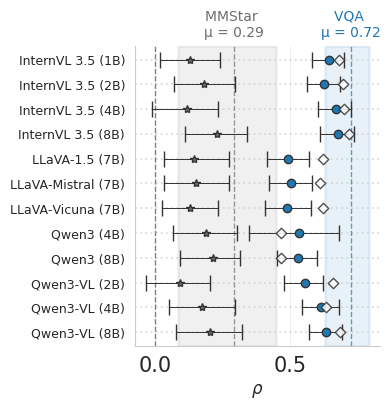

In [593]:
from utils.plots import plot_model_corr 

fig, ax = plt.subplots(figsize=(4, 0.35 * len(model_order))) # figsize=(6, 3 + 0.4 * len(models)))  
# ax.set_xlim(-0.1, 0.45)

ax = plot_model_corr(ax, rhos_mm, ci_lows_mm, ci_highs_mm, model_order, 
                    low_mm, high_mm, mu_mm, dataset="MMStar", color="#6E6E6E", marker='*')

ax = plot_model_corr(ax, rhos_acc, ci_lows_acc, ci_highs_acc, model_order, 
                    low, high, mu, dataset="VQA", color="#1f77b4", marker='o')    
ax.scatter(
    rhos_sim + 0.015,  # small horizontal separation,
    np.arange(len(model_order) ),
    marker="D",
    s=28,
    facecolors="white",
    edgecolors="#333333",
    linewidths=1,
    label="Answer similarity",
    alpha=0.85, 
    zorder=5   
)
ax.set_yticklabels(model_order, fontsize=9)
ax.axvline( 0,  color="gray",linestyle="--",linewidth=1 ) ## Reference line at rho = 0  
ax.grid(axis="y", linestyle=":" , linewidth=1.4 , alpha=0.6 )
ax.grid(axis="x", alpha=0.3)  # ax.grid(False, axis="x")  
ax.set_xlabel(r"$\rho$", fontsize=12) #  (Spearman correlation to human consensus) 
ax.set_yticks(np.arange(len(model_order)))
ax.set_yticklabels(model_order) 
ax.invert_yaxis() 
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False) # Clean spines 

# ax.legend(  loc="lower left",     frameon=True,     fontsize=10, )
# plt.title("Model–Human Alignment") 
plt.tight_layout()
plt.show() 

## MG Scatterplots 

In [ ]:
sim_mg = vv.test_model_mg_sim.groupby(['model', 'finetuned'])['MG'].mean().reset_index()
acc_mg = vv.test_model_mg_acc.groupby(['model', 'finetuned'])['MG'].mean().reset_index() # .dropna(axis=1).groupby(['model', 'finetuned']).mean(numeric_only=True)
vqa_mg = pd.merge(sim_mg, acc_mg, suffixes=('_sim', '_acc'), how='inner', on=['model', 'finetuned'])
vqa_mg['family'] = vqa_mg['model'].map(get_family)
vqa_mg['model_size'] = vqa_mg['model'].map(parse_size)      

finetuned_list = ['Pretrained', 'JS VQA (GT)', 'JS-Blind VQA (n=15)', 'SFT-Blind VQA',  'SFT-VQA'] 
pcorr = pd.merge(corr[corr['metric'] == 'correct'], vqa_mg, on=['model', 'finetuned']) 
pcorr = pcorr[pcorr['finetuned'].isin(finetuned_list)] # ,'JS-Blind VQA (n=10)', 'SFT-Blind MMStar', 'JS-Blind MMStar (n=15)',  

sim_corr = pd.merge(corr[corr['metric'] == 'answer_similarity'], vqa_mg, on=['model', 'finetuned']) 
sim_corr = sim_corr[sim_corr['finetuned'].isin(finetuned_list)] # ,'JS-Blind VQA (n=10)', 'SFT-Blind MMStar', 'JS-Blind MMStar (n=15)',  

In [768]:

regime_markers = {
    'Pretrained': 'o', 
    'JS VQA (GT)': 's', 
    'SFT-VQA': 's',
    'JS-Blind VQA (n=15)': '^',  
    'SFT-Blind VQA': '^', 
}

In [801]:
JS_REGIMES  = ["JS VQA (GT)", "JS-Blind VQA (n=15)"]
SFT_REGIMES = ["SFT-Blind VQA", "SFT-VQA"] 
REGIME_GROUPS = {
    "JS":  JS_REGIMES,
    "SFT": SFT_REGIMES,
}
family_markers = {
    'InternVL': 'o', 
    'LLaVA': 's', 
    'Qwen': '^',
}
regime_colors  = {
    # Ground‑truth supervised (blue family)
    "JS VQA (GT)":  "#4C72B0",  # darker muted blue
    "SFT-VQA":      "#8DA0CB",  # lighter blue

    # Blind training (gray family)
    "JS-Blind VQA (n=15)": "#D9A066",  
    "SFT-Blind VQA":       "#B65F2E",  

    "Pretrained": "#B0B0B0"
}
family_colors = {'InternVL': '#4C72B0',
 'LLaVA': '#DD8452',
 'Qwen': '#55A868'}  

In [838]:
pcorr.to_csv('./correlations/pcorr.csv')
sim_corr.to_csv('./correlations/simcorr.csv')

0.7240451289687589 0.04785911316423045
0.7240451289687589 0.04785911316423045
0.7240451289687589 0.04785911316423045


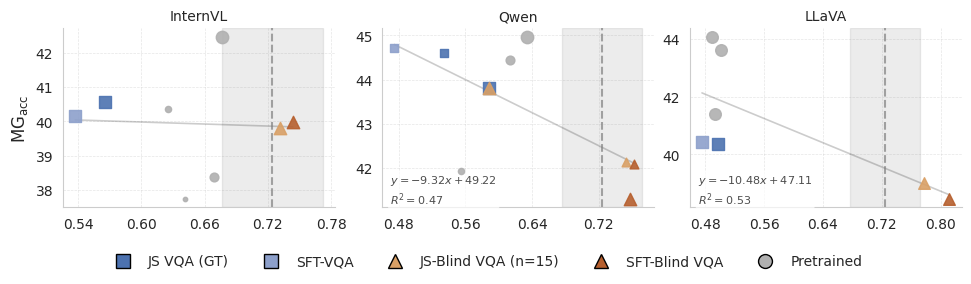

In [855]:

from matplotlib.lines import Line2D
# --- Prepare subplot figures: 2 rows × 3 cols, share x, handle >6 families gracefully ---
from itertools import chain

def plot_family_scatter(
    df, axes_flat,
    families,
    value_col,
    ylabel, 
    xlabel, 
    xshared=True, 
    subplot_row=0,
    mu=None,
    sd=None,
):
    n_panels = len(families)
    
    for idx, fam in enumerate(families):
        if idx >= max_panels: break
        ax = axes_flat[idx]
        fam_df = df[df['family'] == fam]
        # Plot regression line
        if len(fam_df) >= 2:
            x = fam_df["theta_hat"]
            y = fam_df[value_col]
            slope, intercept = np.polyfit(x, y, 1)
            reg_x = np.linspace(x.min(), x.max(), 50)
            reg_y = slope * reg_x + intercept
            ax.plot(reg_x, reg_y, color="black", alpha=0.2, lw=1.2, zorder=2)

            # Regression R^2 and annotation
            y_pred = slope * x + intercept
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan
            eqn = f"$y = {slope:.2f}x"
            if intercept >= 0:
                eqn += f" + {intercept:.2f}$"
            else:
                eqn += f" - {abs(intercept):.2f}$"
            eqn += f"\n$R^2 = {r_squared:.2f}$"
            # Place eqn at top left for readability, using axes coords
            if r_squared > 0.3:
                ax.annotate(
                    eqn,
                    xy=(0.03, 0), xycoords="axes fraction",
                    xytext=(0, 0.3), textcoords="offset points",
                    fontsize=8,
                    color="black",
                    alpha=0.7,
                    ha='left', va='bottom',
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
                )
        # Add reference region (mu and sd) if provided
        print(mu, sd)
        if mu is not None and sd is not None:
            # Shaded region: mu ± sd
            ax.axvspan(mu - sd, mu + sd, alpha=0.15, color='gray', zorder=1)
            # Vertical line at mu
            ax.axvline(mu, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, zorder=2, label='Human mean')
        
        # Scatter points
        for _, row in fam_df.iterrows():
            ax.scatter(
                row["theta_hat"],
                row[value_col],
                marker=regime_markers.get(row["finetuned"], "o"),
                facecolor=regime_colors[row["finetuned"]],
                s=row['model_size'] * 10,
                linewidth=1.0,
                alpha=0.9,
                zorder=3,
            )

        if idx % ncols == 0:
            ax.set_ylabel(ylabel)
        
        if subplot_row == 0: 
            ax.set_title(fam, fontsize=10)
            # ax.tick_params(labelbottom=False) 
        else: 
            ax.set_xlabel(xlabel)

        ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=5))
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
        ax.set_axisbelow(True)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

nrows, ncols = 1, 3
max_panels = nrows * ncols
fig, axes = plt.subplots(nrows, ncols, 
                            figsize=(3.2 * ncols, 2.3 * nrows),
                            constrained_layout=True,
                            # sharex=True, # if xshared else False,
                            squeeze=False)

axes_flat = axes.flatten()
# Plot MG_acc (accuracy) by family
acc_families = list(pcorr['family'].unique())
plot_family_scatter(
    pcorr[pcorr['dataset'] == 'VQA'], axes_flat[:len(acc_families)], acc_families, "MG_acc", r"MG$_{\mathrm{acc}}$", r"${\rho}$", xshared=True,
    mu=mu_vqa, sd=sd_vqa, subplot_row=0
)

# Plot MG_sim (similarity) by family
# sim_families = list(sim_corr['family'].unique())
# plot_family_scatter(
#     sim_corr, axes_flat[len(acc_families):len(acc_families)+len(sim_families)], sim_families, "MG_sim", r"MG$_{\mathrm{sim}}$", r"${\rho}$", xshared=True,
#     mu=mu_vqa, sd=sd_vqa, subplot_row=1
# )

# Prepare regime legend handles (markers and colors by regime ie. finetuned)
regime_handles = [
    Line2D(
        [0], [0],
        marker=regime_markers.get(f, "o"),
        color='w',
        markerfacecolor=regime_colors[f],
        markeredgecolor='black',
        markersize=10,
        linestyle="",
        label=f
    )
    for f in regime_colors
]

# Prepare list of handles and labels in order
legend_handles = regime_handles
# Optionally, insert empty 'spacer' handle for visual separation (not necessary)

# Make a big legend at the bottom with 5 columns, outside the plot
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=5,
    bbox_to_anchor=(0.5, -0.2),  # adjust as needed for space below
    frameon=False,
    fontsize=10,
    # title="Regime (color) and Family (marker shape)",
    title_fontsize=11,
)

plt.show()

In [ ]:

    # Hide any unused subplots
    for j in range(n_panels, max_panels):
        axes_flat[j].set_visible(False)
    
    # Ensure x-tick labels are visible on bottom row subplots (important when sharex=True)
    # Find the actual bottom row (last row that has data)
    bottom_row = (n_panels - 1) // ncols
    for idx in range(bottom_row * ncols, min((bottom_row + 1) * ncols, n_panels)):
        axes_flat[idx].tick_params(labelbottom=True)
        axes_flat[idx].set_xlabel(xlabel)
        
    bottom_row_indices = list(range(max_panels - ncols, max_panels))
    if n_panels < max_panels:
        # Only keep axes that are actually plotted
        bottom_row_indices = [i for i in bottom_row_indices if i < n_panels]
    
    # Only add legend if we have visible bottom row subplots
    if bottom_row_indices:
        handles = [
            plt.Line2D(
                [0],[0],
                color='white',
                marker=regime_markers.get(f, "o"),
                markerfacecolor=regime_colors[f],
                markeredgecolor='black',
                markersize=10,
                linestyle="",
                label=f
            ) for f in regime_colors
        ]
        # Add legend to the leftmost visible bottom-row subplot
        axes_flat[bottom_row_indices[0]].legend(
            handles=handles,
            loc='best',  # Place inside the plot, at best location
            ncol=1,      # single column, easier to see inside
            borderaxespad=0.6,
            frameon=True,
            fontsize=9,
            fancybox=True,
            shadow=False
        )

In [797]:
from scipy import stats
from utils.plot_corr import * 

x_col = "theta_hat"
y_col = "MG_sim" 
delta_df = get_delta_df(sim_corr) 
regression_stats = get_stats(delta_df) 

scatterplot_delta_alignment_vs_mg(
    delta_df,
    regression_stats= regression_stats, 
    title = 'answer_similarity',
    EQ_POS = {
    "JS":  (0.6, 0.85),
    "SFT": (0.6, 0.75),
    }, 
    colors= regime_colors,          # keyed by finetuned regime
    markers= family_markers, 
    figsize=(11,8) ) 

NameError: name 'pd' is not defined

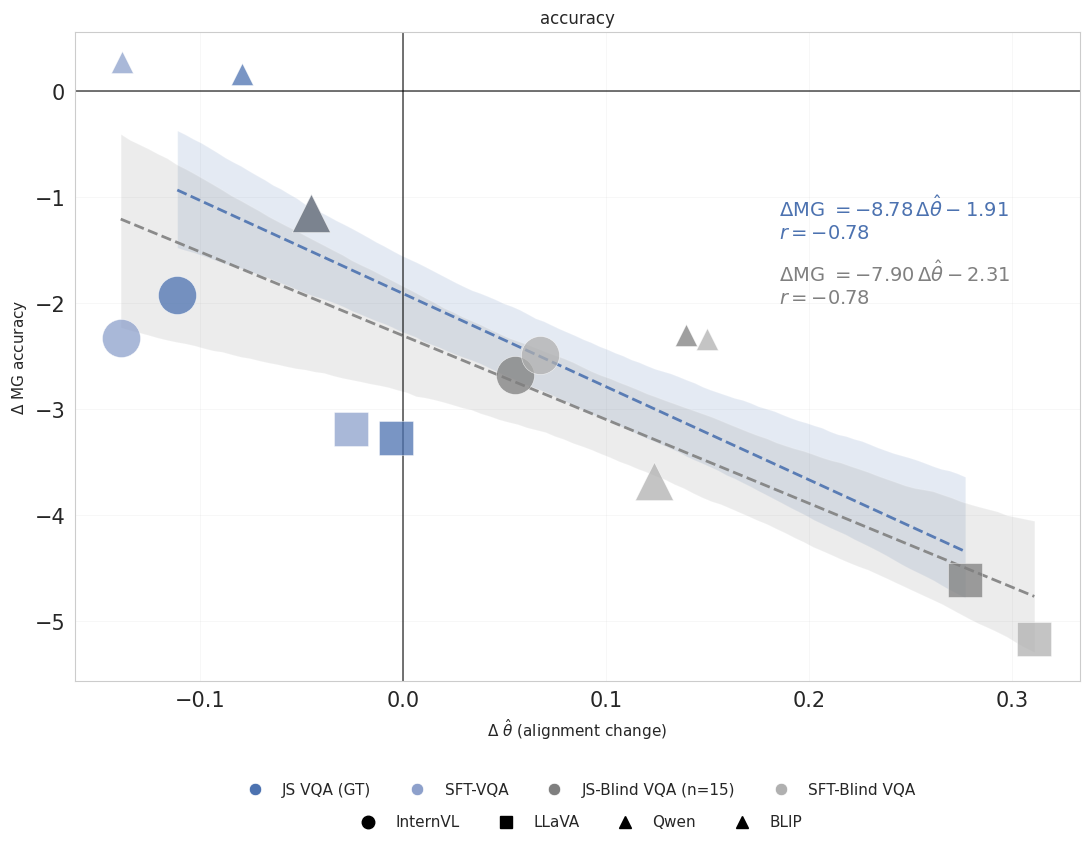

In [655]:
x_col = "theta_hat"
y_col = "MG_acc" 
delta_df = get_delta_df(pcorr[pcorr['dataset'] == 'VQA'])

scatterplot_delta_alignment_vs_mg(
    delta_df,
    title = 'accuracy',
    regression_stats = get_stats(delta_df), 
    EQ_POS= {
    "JS":  (0.7, 0.75),
    "SFT": (0.7, 0.65),
    }, 
    colors= regime_colors,          # keyed by finetuned regime
    markers= family_markers ,
    figsize=(11,8) ) 